In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import itertools

In [2]:
class TdCARS:
    """
    Class to simulate Time-Delayed Coherent Anti-Stokes Raman Scattering (TdCARS).
    Version 1.0
    """
    def __init__(self,l1,l2,tp1,tp2,tp3,tmin,tmax,floor,nuR1,T21,A1,phi1):
        """
        Initializes the TdCARS class with given parameters.
        l1, l2 : Wavelengths of pump and Stokes pulses [nm]
        tp1, tp2, tp3 : Pulse durations of pump, Stokes, and probe [fs]
        tmin, tmax : Time delay range [fs]
        floor : Baseline signal level
        nuR1 : List of Raman shift frequency [cm^-1]
        T21 : List of Dephasing time [fs]
        A1 : List of Amplitudes of Raman modes [au]
        """
        self.c = 2.99792e10  # speed of light [cm/s]
        self.l1 = l1
        self.l2 = l2
        self.nuR1 = nuR1
        self.tp1 = tp1
        self.tp2 = tp2
        self.tp3 = tp3
        self.tmin = tmin
        self.tmax = tmax
        self.floor = floor
        self.T21 = T21
        self.A1 = A1
        self.phi1 = phi1
        w1 = 1e7 * 2 * np.pi * self.c / self.l1
        w2 = 1e7 * 2 * np.pi * self.c / self.l2
        self.wt = w1 - w2
        wR1 = 2 * np.pi * self.nuR1 * self.c
        self.wr1 = (self.wt - wR1) * 1e-15
        self.nut = self.wt / (2 * np.pi * self.c)
    
    def CARS_simulation_FG(self):
        """
        Simulates Coherent Anti-Stokes Raman Scattering (CARS) signal.

        Returns:
        td : Time delay array [fs]
        signal : Simulated CARS signal array [a.u.]
        """
        # ---------------------------------------------------------
        # Constants & Input Parameters
        # ---------------------------------------------------------
        norm = 1e-15  # [fs] to [s] conversion factor

        a12 = -2 * np.log(2) * (1/self.tp1**2 + 1/self.tp2**2)

        b21 = -1/self.T21 - 1j*self.wr1

        # ---------------------------------------------------------
        # Time grid
        # ---------------------------------------------------------
        step0 = 5
        step1 = 5
        t1 = np.arange(self.tmin, self.tmax, step1)
        m1 = len(t1)

        lim = 5 * self.tp1
        ts = np.arange(-lim, lim, step0)

        Q = np.zeros(m1, dtype=complex)

        # ---------------------------------------------------------
        # Main integration loop
        # ---------------------------------------------------------
        for j1, t in enumerate(t1):

            if t < -lim:
                hs = np.zeros_like(ts)
            elif t > lim:
                hs = np.ones_like(ts)
            else:
                p1 = int(round((t + lim) / step0))
                hs = np.concatenate((np.ones(p1), np.zeros(len(ts) - p1)))
            #hs = np.heaviside(t-ts,1)
            F1 = hs * (
                self.A1[0] * np.exp(b21[0] * (t - ts) + self.phi1) +
                self.A1[1] * np.exp(b21[1] * (t - ts))
            ) * np.exp(a12 * ts**2)

            Q[j1] = step0 * np.trapezoid(F1)

        Q11 = (norm * np.abs(Q))**2

        # ---------------------------------------------------------
        # Convolution with probe pulse
        # ---------------------------------------------------------
        a3 = -4 * np.log(2) / self.tp3**2
        step2 = 5

        td = np.arange(self.tmin + 5*self.tp3, self.tmax - 5*self.tp3 + step2, step2)
        m2 = len(td)

        signal = np.zeros(m2)

        for j2 in range(m2):
            I3 = np.sqrt(-a3/np.pi) * np.exp(a3 * (t1 - td[j2])**2)
            F2 = Q11 * I3
            signal[j2] = norm * step2 * np.trapezoid(F2) + self.floor

        return td, signal
    
    @staticmethod
    def import_experimental_data(filepath):
        """
        Imports experimental CARS data from a CSV file.
        The CSV file should have 4 columns: time delay (fs), signal (a.u.)., int_signal(a.u.) and attenuation(a.u.)
        filepath : Path to the CSV file
        Returns:
        td_exp : Time delay array from experimental data [fs]
        signal_exp : CARS signal array from experimental data [a.u.]
        int_signal : Integrated signal array from experimental data [a.u.]
        attenuation : Attenuation values array from experimental data [a.u.]
        """
        data = np.loadtxt(filepath, delimiter='\t')
        td_exp = data[:,0]
        signal_exp = data[:,1]
       # int_signal = data[:,2]
       # attenuation = data[:,3]
       # return td_exp, signal_exp, int_signal, attenuation
        return td_exp, signal_exp

    @staticmethod
    def correct_experimental_data(signal_exp, attenuation, corrections):
        """
        Corrects the experimental CARS signal for incorrect attenuations.
        signal_exp : Experimental CARS signal [a.u.]
        attenuation : list of attenuation values [a.u.]
        corrections : 2D array of attenuation corrections [[old1,new1],[old2,new2],...]
        Returns:
        signal_exp_corrected : Corrected experimental CARS signal [a.u.]
        """
        att_exp = attenuation.copy()
        att_bofr = np.append(corrections[:,0],[ x * y for x, y in itertools.combinations(corrections[:,0], 2)])
        att_aftr = np.append(corrections[:,1],[ x * y for x, y in itertools.combinations(corrections[:,1], 2)])
        for i in range(len(att_bofr)):
            att_exp[att_exp == att_bofr[i]] = att_aftr[i]
        signal_exp_corrected = signal_exp/attenuation*att_exp
        return signal_exp_corrected
    
    @staticmethod
    def show_notes(cars_file_path):
        """
        Displays the notes associated with the CARS data file.
        cars_file_path : Path to the CARS data file
        Returns:
        df : DataFrame containing the notes
        """
        cars_notes_file_path = cars_file_path[:-4]+"_Notes.dat"
        df = pd.read_csv(cars_notes_file_path, sep="\t")
        return df
    
    @staticmethod
    def get_T2(td_exp, signal_exp_corrected, td1, td2, show_plot=False):
        """
        Estimates the dephasing time T2 from the experimental CARS data.
        td_exp : Time delay array from experimental data [fs]
        signal_exp_corrected : Corrected CARS signal from experimental data [a.u.]
        td1, td2 : Time delay range for fitting [fs]
        show_plot : If True, displays the fitting plot
        Returns:
        T2 : Estimated dephasing time [fs]
        dT2 : Uncertainty in the estimated dephasing time [fs]
        """
        x = td_exp[(td_exp>=td1) & (td_exp<=td2)]
        y = np.log(signal_exp_corrected[(td_exp>=td1) & (td_exp<=td2)])
        (m, b), cov = np.polyfit(x, y, 1, cov=True)
        dm = 2*np.sqrt(cov[0, 0])  # uncertainty in slope 95% confidence interval
        T2, dT2 = -2/m, 2*dm/m**2
        if show_plot:
            fig = plt.figure(figsize=(10,5))
            plt.subplot(121)
            plt.semilogy(td_exp, signal_exp_corrected, 'ko', mfc='none', label='All Transient Data')
            plt.semilogy(x, np.exp(y), 'bo', mfc='none', label='Decay Data')
            plt.xlabel('Time Delay (fs)')
            plt.ylabel('CARS Signal (a.u.)')
            plt.title('CARS Signal: Experimental Data')
            plt.legend()
            plt.subplot(122)
            plt.plot(x,y,'bo', mfc='none', label='Data for Linear Fit')
            plt.plot(x, m*x + b, 'r-', label='Linear Fit'+r", slope={:.0f}±{:.0f} fs".format(-2/m,2*dm/m**2))
            plt.plot(x, (m+dm)*x + b, 'r--', label='+2σ')
            plt.plot(x, (m-dm)*x + b, 'r--', label='-2σ')
            plt.xlabel('Time Delay (fs)')
            plt.ylabel('ln(CARS Signal)')
            plt.title('Logarithmic Decay Fit')
            plt.legend()
            plt.savefig("CARS_Fit.png", dpi=1000, bbox_inches="tight")
            plt.show()
            
        return T2, dT2

In [3]:
#office
#cars_file_path = r"C:\Users\jpikul\OneDrive - University of Rhode Island\URI\Ganikhanov Lab\Research\APL_special_issue_2025\Fig_2\LNB_4.dat"

#Apt
cars_file_path = r"D:\Academic\URI\Research\Data_and_Results\experimental_data\CARS\2026\Feb_19\PETN_4.dat"

#Mac
#cars_file_path = r"/Users/jafarpikul/Library/CloudStorage/OneDrive-UniversityofRhodeIsland/URI/Ganikhanov Lab/Research/APL_special_issue_2025/Fig_2/LNB_4.dat"
td_exp, signal_exp = TdCARS.import_experimental_data(cars_file_path)


#corrections = np.array([[120,100], [650,500], [30,30]])
#signal_exp_corrected = TdCARS.correct_experimental_data(signal_exp, attenuation, corrections)

#TdCARS.show_notes(cars_file_path)

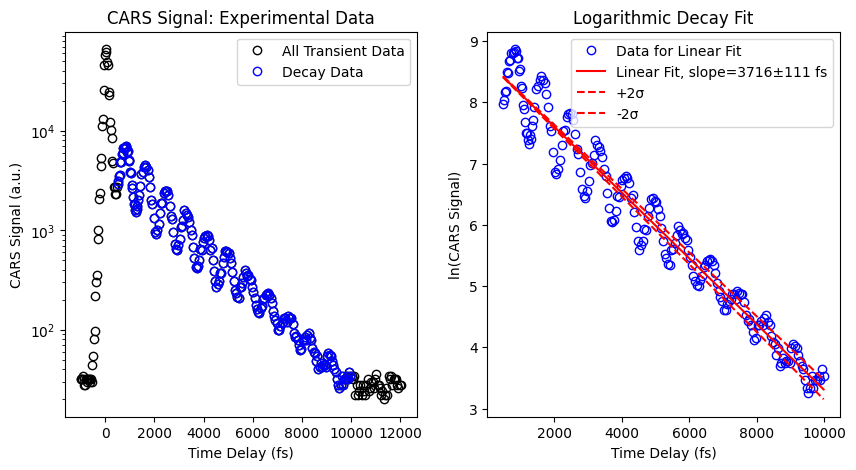

In [5]:
td1,td2 = 500,10000 #Time delay range for fitting [fs]
T2, dT2 = TdCARS.get_T2(td_exp, signal_exp, td1, td2, show_plot=True)

In [7]:
TdCARS.show_notes(cars_file_path)

,DET,Syncerity CCD
0,SMP,PETN
1,P3 (TiS),150
2,P1 (OPO1),275
3,P2 (OPO2),240
4,Polarizations,All parallel
5,Ti-Sa,810
6,OPO1,1015
7,OPO2,1160
8,MONO,738
9,Slit,0.5


In [14]:
1e7*(1/1015-1/1160) # Raman mode in 1/cm

1231.5270935960584

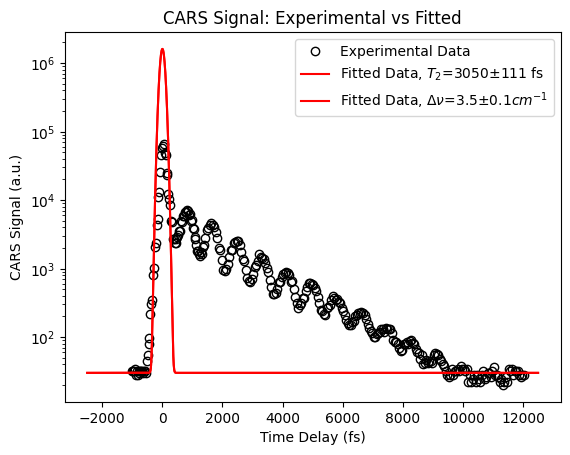

In [54]:
#wl1,wl2 = 1016.8,1114.2  # Pump and Stokes wavelengths [nm], need to check it; get from the note file
wl1,wl2 = 1015, 1160 
tp1,tp2,tp3 = 215, 215, 100  # Pulse durations [fs]
tmin,tmax = -3000,13000  # Time delay range [fs]
floor = 30  # Baseline signal level
nuR = 1231 # Raman mode in 1/cm
T2 = 3000
nuR1 = np.array([800, 840.5, 880, 0])  # Raman shift frequencies [cm^-1]
T21 = np.array([3050, 3405, 2400, 10])  # Dephasing times [fs]
A1 = np.array([1.6e24, 1.7e24, 0, 130e24])  # Amplitudes of Raman modes [au], we only have one raman mode
phi1 = 0  # Phase of first Raman mode [rad]

CARS = TdCARS(wl1,wl2,tp1,tp2,tp3,tmin,tmax,floor,nuR1,T21,A1,phi1)
td_fit, signal_fit = CARS.CARS_simulation_FG()

dnu = 1/np.pi/3e10/T2/1e-15 # inverse cm^{-1} = delta nu; 29.9 +- 0.3 cm^{-1}
dbnu= dT2/T2*dnu # uncertainty for dnu, 0.3

plt.semilogy(td_exp, signal_exp, 'ko', mfc='none', label='Experimental Data')
plt.semilogy(td_fit, signal_fit, 'r-', label='Fitted Data, '+r"$T_2$={:.0f}$\pm${:.0f}".format(T21[0],dT2)+" fs")
plt.semilogy(td_fit, signal_fit, 'r-', label='Fitted Data, '+r"$\Delta \nu$={:.1f}$\pm${:.1f}".format(dnu,dbnu)+ r"$cm^{-1}$")
plt.xlabel('Time Delay (fs)')
plt.ylabel('CARS Signal (a.u.)')
plt.title('CARS Signal: Experimental vs Fitted')
plt.legend()
#plt.savefig("CARS.png", dpi=1000, bbox_inches="tight")
plt.show()

In [ ]:
# This is how you find the floor
np.mean(signal_exp[0:10])

np.float64(31.2)

In [55]:
dnu = 1/np.pi/3e10/T2/1e-15 # inverse cm^{-1} = delta nu; 29.9 +- 0.3 cm^{-1}
dnu

3.53677651315323

In [31]:
dT2/T2*dnu # uncertainty for dnu, 0.3

np.float64(0.29071630081060895)

In [56]:
#wl1, wl2 = 1014, 1087  # nm

OmegaR = 1e7*(1/wl1 - 1/wl2)   # cm^-1
print(OmegaR)

1231.5270935960584


In [57]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------- global style (match code1) ----------------
plt.rcParams.update({
    "font.size": 14,          # base font size
    "axes.labelsize": 16,     # x/y labels
    "legend.fontsize": 14,    # legend
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

# ---------------- paths ----------------
# #office
# folder = Path(
#     r"C:\Users\jpikul\OneDrive - University of Rhode Island\URI\Ganikhanov Lab\Research\APL_special_issue_2025\Fig_2"
# )


#Apt
folder = Path(
    r"C:\Users\Jafar Pikul\OneDrive - University of Rhode Island\URI\Ganikhanov Lab\Research\APL_special_issue_2025\Fig_2"
)

# ---------------- parameters ----------------
ATT   = np.array([1e4, 1e3, 300, 30, 1])
coeff = np.array([1, 3.5, 1e2, 1e2, 5e3])
floor = 1000

files = [
    "CARS_spectrum_td=2fs.dat",
    "CARS_spectrum_td=402fs.dat",
    "CARS_spectrum_td=1002fs.dat",
    "CARS_spectrum_td=1502fs.dat",
    "CARS_spectrum_td=2002fs.dat",
]

labels = [
    "0 fs (×1)",
    "400 fs (×3.5)",
    "1000 fs (×100)",
    "1500 fs (×100)",
    "2000 fs (×5000)",
]

colors = ["b", "g", "r", "k", "c"]

# ---------------- plot ----------------
plt.figure(figsize=(8, 5))

for i, fname in enumerate(files):
    wl, signal = np.loadtxt(folder / fname, delimiter=",", unpack=True)
    power = (signal - floor) * ATT[i] * coeff[i]
    plt.plot(wl, power, color=colors[i], linewidth=2, label=labels[i])

# ---------------- formatting ----------------
plt.xlim(760, 782)
plt.ylim(-1, 3e7)

plt.xlabel("wavelength [nm]")
plt.ylabel("CARS signal [cts]")

plt.legend(loc="upper right")
plt.tight_layout()

# ---------------- save / show ----------------
plt.savefig("CARS_spectrum_t3.tiff", dpi=700, bbox_inches="tight")
plt.show()


FileNotFoundError: C:\Users\Jafar Pikul\OneDrive - University of Rhode Island\URI\Ganikhanov Lab\Research\APL_special_issue_2025\Fig_2\CARS_spectrum_td=2fs.dat not found.

<Figure size 800x500 with 0 Axes>

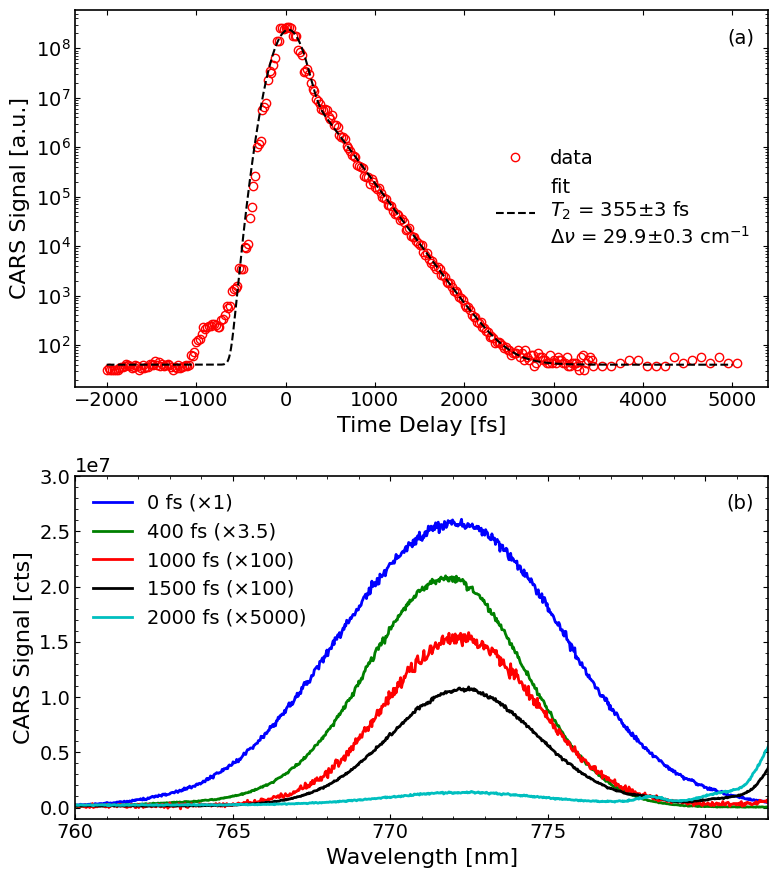

In [7]:
#Figure2
import matplotlib.pyplot as plt
import numpy as np

# ---------------- figure & layout ----------------
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(8, 9),
    gridspec_kw={"height_ratios": [1.1, 1]},
    sharex=False
)

# =================================================
# TOP PANEL — Time-domain CARS (code1 style)
# =================================================
ax1.semilogy(td_exp, signal_exp, 'ro', mfc='none', label='data')
ax1.semilogy(
    td_fit,
    signal_fit,
    '--k',
    label=
        "fit\n"
        + f"$T_2$ = {T21[0]:.0f}\u00B1{dT2:.0f} fs\n"
        + f"$\\Delta\\nu$ = {dnu:.1f}\u00B1{dbnu:.1f} cm$^{{-1}}$"
)




ax1.set_xlabel("Time Delay [fs]")
ax1.set_ylabel("CARS Signal [a.u.]")
#ax1.set_title("CARS Signal: Experimental vs Fitted")
ax1.legend()
ax1.legend(frameon=False)

ax1.tick_params(labelsize=14)

# =================================================
# BOTTOM PANEL — Spectrum (code2)
# =================================================
for i, fname in enumerate(files):
    wl, signal = np.loadtxt(folder / fname, delimiter=",", unpack=True)
    power = (signal - floor) * ATT[i] * coeff[i]
    ax2.plot(wl, power, color=colors[i], linewidth=2, label=labels[i])

#ax2.set_xlim(760, 782)
ax2.set_xlim(760, 782)
ax2.set_xticks(np.arange(760, 785, 5))
ax2.minorticks_on()
#ax2.set_ylim(-1, 3e7)
ax2.set_ylim(-1e6, 3e7)
#ax2.set_ylim(-5e5, 3e7)


ax2.set_xlabel("Wavelength [nm]")
ax2.set_ylabel("CARS Signal [cts]")
ax2.legend()
ax2.legend(frameon=False)
ax2.tick_params(labelsize=14)

#ax2.tick_params(axis='x', pad=10) 


# ---- panel labels (top-right, non-bold) ----
ax1.text(
    0.98, 0.95, '(a)',
    transform=ax1.transAxes,
    fontsize=14,   # same scale as legend/ticks
    va='top',
    ha='right'
)

ax2.text(
    0.98, 0.95, '(b)',
    transform=ax2.transAxes,
    fontsize=14,
    va='top',
    ha='right'
)



for ax in (ax1, ax2):
    ax.tick_params(
        direction='in',   # ticks inside
        which='both',     # major + minor
        top=True,         # show top x-axis ticks
        bottom=True,
        left=True,
        right=True        # show right y-axis ticks
    )


# ---------------- final polish ----------------
for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

plt.tight_layout()
#plt.savefig("CARS_combined.png", dpi=1000, bbox_inches="tight")
plt.show()


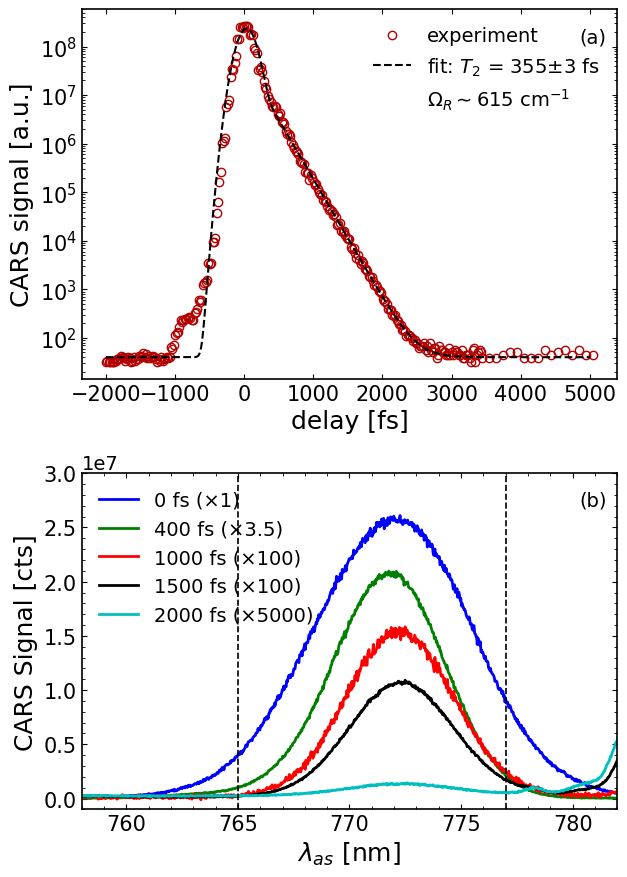

In [8]:

import matplotlib.pyplot as plt
import numpy as np

# =================================================
# Figure & layout
# =================================================
fig, (ax1, ax2) = plt.subplots(2, 1,
    #figsize=(8, 9),
    #figsize=(6.69, 9),   # narrower width, same height
    figsize=(6.5, 9),   # narrower width, same height
    gridspec_kw={"height_ratios": [1.1, 1]},
    sharex=False
)

# =================================================
# TOP PANEL — Time-domain CARS (code1 style)
# =================================================

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 1) Plot lines and CAPTURE handles
line_data, = ax1.semilogy(td_exp, signal_exp, 'o', mfc='none', mec=(0.7, 0.0, 0.0), color=(0.7, 0.0, 0.0))
line_fit,  = ax1.semilogy(td_fit,  signal_fit,  '--k')

# 2) Dummy handle for the 2nd text-only legend row
dummy = Line2D([], [], linestyle='None')

# 3) Build legend ONCE (do not call ax1.legend() anywhere else)
ax1.legend(
    handles=[line_data, line_fit, dummy],
    labels=[
        "experiment",
        f"fit: $T_2$ = {T21[0]:.0f}\u00B1{dT2:.0f} fs",
       #f"$\\Delta\\nu$ = {dnu:.1f}\u00B1{dbnu:.1f} cm$^{{-1}}$"
        # f"$\Omega_R$ = {OmegaR:.1f} cm$^{{-1}}$"
        #f"$\\Omega_{{\\mathrm{{R}}}}$ = {OmegaR:.0f} cm$^{{-1}}$"
        #f"$\\Omega_R$ = {OmegaR:.1f} cm$^{{-1}}$"
        f"$\\Omega_R$$\\sim{615}$ cm$^{{-1}}$"


    ],
    frameon=False,
    loc="upper right"   # change if you want
)

# ax1.semilogy(td_exp, signal_exp, 'ro', mfc='none', label='data')
# ax1.semilogy(
#     td_fit,
#     signal_fit,
#     '--k',
#     label=(
#         "fit\n"
#         + f"$T_2$ = {T21[0]:.0f}\u00B1{dT2:.0f} fs\n"
#         + f"$\\Delta\\nu$ = {dnu:.1f}\u00B1{dbnu:.1f} cm$^{{-1}}$"
#     )
# )

ax1.set_xlabel("delay [fs]",  fontsize=18)
ax1.set_ylabel("CARS signal [a.u.]", fontsize=18)
# ax1.set_title("CARS Signal: Experimental vs Fitted")
# ax1.legend()
# ax1.legend(frameon=False)
ax1.tick_params(labelsize=15)

# Panel label (top-right, non-bold)
ax1.text(
    0.98, 0.95, '(a)',
    transform=ax1.transAxes,
    fontsize=14,
    va='top',
    ha='right'
)

# =================================================
# BOTTOM PANEL — Spectrum (code2)
# =================================================
for i, fname in enumerate(files):
    wl, signal = np.loadtxt(folder / fname, delimiter=",", unpack=True)
    power = (signal - floor) * ATT[i] * coeff[i]
    ax2.plot(wl, power, color=colors[i], linewidth=2, label=labels[i])

ax2.set_xlim(758, 782)
ax2.set_xticks(np.arange(760, 785, 5))
ax2.minorticks_on()

# --- vertical guide lines ---
ax2.axvline(765, color='k', linestyle='--', linewidth=1.2)
# line1 = ax2.axvline(765, color='k', linewidth=1.5)
# line1.set_dashes([1, 1, 3, 1])  # short dash, gap, long dash, gap
ax2.axvline(777, color='k', linestyle='--', linewidth=1.2)

ax2.set_ylim(-1e6, 3e7)
# ax2.set_ylim(-5e5, 3e7)

ax2.set_xlabel(r"$\lambda_{as}$ [nm]", fontsize=18)
ax2.set_ylabel("CARS Signal [cts]", fontsize=18)
ax2.legend()
ax2.legend(frameon=False)
ax2.tick_params(labelsize=15)

# ax2.tick_params(axis='x', pad=10)

# Panel label (top-right, non-bold)
ax2.text(
    0.98, 0.95, '(b)',
    transform=ax2.transAxes,
    fontsize=14,
    va='top',
    ha='right'
)

# =================================================
# Shared axis styling (ticks and spines)
# =================================================
for ax in (ax1, ax2):
    ax.tick_params(
        direction='in',
        which='both',
        top=True,
        bottom=True,
        left=True,
        right=True
    )

for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

# =================================================
# Layout & export
# =================================================
plt.tight_layout()
# plt.savefig("CARS_combined.png", dpi=1000, bbox_inches="tight")
plt.savefig("Fig_2.tif",dpi=400, format="tiff",pil_kwargs={"compression": "tiff_lzw"}, bbox_inches="tight")
plt.show()


In [36]:
wl1, wl2 = 1016.8, 1114.2  # nm

OmegaR_cm1 = 1e7*(1/wl1 - 1/wl2)   # cm^-1
print(OmegaR_cm1)


859.726404341015


In [37]:
wl1, wl2 = 1014, 1087  # nm

OMEGA_R = 1e7*(1/wl1 - 1/wl2)   # cm^-1
print(OMEGA_R)

662.3009241366051


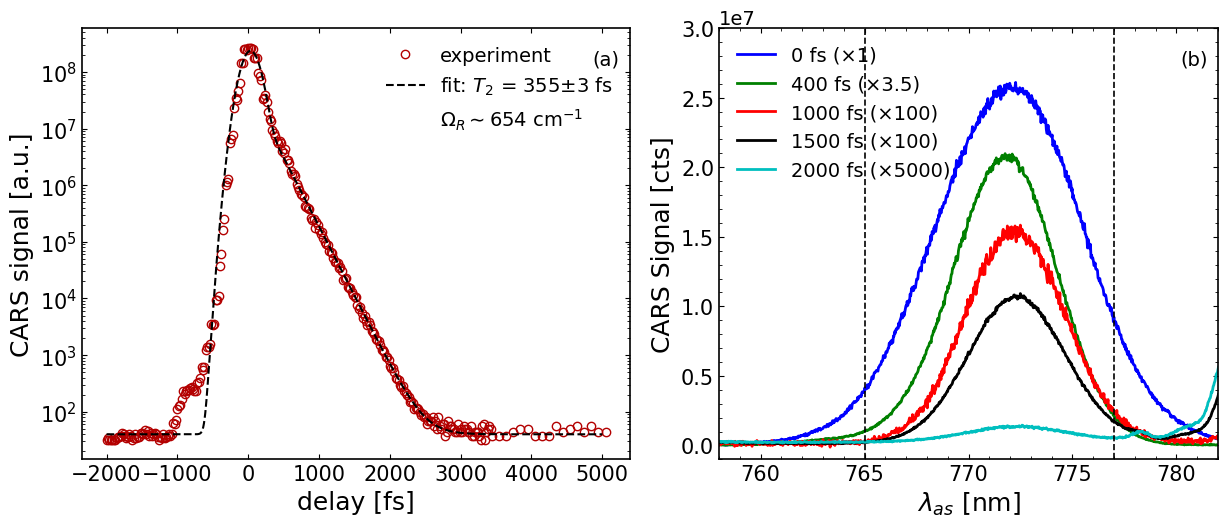

In [41]:

import matplotlib.pyplot as plt
import numpy as np

# =================================================
# Figure & layout
# =================================================
fig, (ax1, ax2) = plt.subplots(1, 2,
    #figsize=(8, 9),
    #figsize=(6.69, 9),   # narrower width, same height
    #figsize=(6.5, 9),   # narrower width, same height
    figsize=(12.5, 5.5),   # narrower width, same height
    gridspec_kw={"width_ratios": [1.1, 1]},
    sharex=False
)

# =================================================
# TOP PANEL — Time-domain CARS (code1 style)
# =================================================

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 1) Plot lines and CAPTURE handles
line_data, = ax1.semilogy(td_exp, signal_exp, 'o', mfc='none', mec=(0.7, 0.0, 0.0), color=(0.7, 0.0, 0.0))
line_fit,  = ax1.semilogy(td_fit,  signal_fit,  '--k')

# 2) Dummy handle for the 2nd text-only legend row
dummy = Line2D([], [], linestyle='None')

# 3) Build legend ONCE (do not call ax1.legend() anywhere else)
ax1.legend(
    handles=[line_data, line_fit, dummy],
    labels=[
        "experiment",
        f"fit: $T_2$ = {T21[0]:.0f}\u00B1{dT2:.0f} fs",
       #f"$\\Delta\\nu$ = {dnu:.1f}\u00B1{dbnu:.1f} cm$^{{-1}}$"
        # f"$\Omega_R$ = {OmegaR:.1f} cm$^{{-1}}$"
        #f"$\\Omega_{{\\mathrm{{R}}}}$ = {OmegaR:.0f} cm$^{{-1}}$"
        #f"$\\Omega_R$ = {OmegaR:.1f} cm$^{{-1}}$"
        f"$\\Omega_R$$\\sim{654}$ cm$^{{-1}}$"


    ],
    frameon=False,
    loc="upper right"   # change if you want
)

# ax1.semilogy(td_exp, signal_exp, 'ro', mfc='none', label='data')
# ax1.semilogy(
#     td_fit,
#     signal_fit,
#     '--k',
#     label=(
#         "fit\n"
#         + f"$T_2$ = {T21[0]:.0f}\u00B1{dT2:.0f} fs\n"
#         + f"$\\Delta\\nu$ = {dnu:.1f}\u00B1{dbnu:.1f} cm$^{{-1}}$"
#     )
# )

ax1.set_xlabel("delay [fs]",  fontsize=18)
ax1.set_ylabel("CARS signal [a.u.]", fontsize=18)
# ax1.set_title("CARS Signal: Experimental vs Fitted")
# ax1.legend()
# ax1.legend(frameon=False)
ax1.tick_params(labelsize=15)

# Panel label (top-right, non-bold)
ax1.text(
    0.98, 0.95, '(a)',
    transform=ax1.transAxes,
    fontsize=14,
    va='top',
    ha='right'
)

# =================================================
# BOTTOM PANEL — Spectrum (code2)
# =================================================
for i, fname in enumerate(files):
    wl, signal = np.loadtxt(folder / fname, delimiter=",", unpack=True)
    power = (signal - floor) * ATT[i] * coeff[i]
    ax2.plot(wl, power, color=colors[i], linewidth=2, label=labels[i])

ax2.set_xlim(758, 782)
ax2.set_xticks(np.arange(760, 785, 5))
ax2.minorticks_on()

# --- vertical guide lines ---
ax2.axvline(765, color='k', linestyle='--', linewidth=1.2)
# line1 = ax2.axvline(765, color='k', linewidth=1.5)
# line1.set_dashes([1, 1, 3, 1])  # short dash, gap, long dash, gap
ax2.axvline(777, color='k', linestyle='--', linewidth=1.2)

ax2.set_ylim(-1e6, 3e7)
# ax2.set_ylim(-5e5, 3e7)

ax2.set_xlabel(r"$\lambda_{as}$ [nm]", fontsize=18)
ax2.set_ylabel("CARS Signal [cts]", fontsize=18)
ax2.legend()
ax2.legend(frameon=False)
ax2.tick_params(labelsize=15)

# ax2.tick_params(axis='x', pad=10)

# Panel label (top-right, non-bold)
ax2.text(
    0.98, 0.95, '(b)',
    transform=ax2.transAxes,
    fontsize=14,
    va='top',
    ha='right'
)

# =================================================
# Shared axis styling (ticks and spines)
# =================================================
for ax in (ax1, ax2):
    ax.tick_params(
        direction='in',
        which='both',
        top=True,
        bottom=True,
        left=True,
        right=True
    )

for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

# =================================================
# Layout & export
# =================================================
plt.tight_layout()
# plt.savefig("CARS_combined.png", dpi=1000, bbox_inches="tight")
plt.savefig("Fig_211.png",dpi=400, format="png",pil_kwargs={"compression": "tiff_lzw"}, bbox_inches="tight")
plt.show()


In [43]:
wl1, wl2 = 1014, 1087  # nm

OMEGA_R = 1e7*(1/wl1 - 1/wl2)   # cm^-1
print(OMEGA_R)

662.3009241366051
